## Comparison intensity vs full wave exit measurement

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import numpy as np
import torch

import quantem as em
from quantem.core import config
from quantem.core.datastructures import Dataset4dstem
from quantem.core.ml import CNN2d
from quantem.core.visualization import show_2d

from importlib.metadata import version # Temporary fix for version check
print(f"quantEM version: {version("quantem")}")

from quantem.core.utils.imaging_utils import detect_bragg_disks, bragg_disks_to_masks

from quantem.diffractive_imaging import (
    PtychographyDatasetRaster,
    DetectorPixelated,
    ObjectDIP,
    ObjectPixelated,
    ProbeDIP,
    ProbePixelated,
    Ptychography,
)

quantEM version: 0.1.8


## Import the data at 10 keV and 100 keV for a 3 layer gold sheet

In [3]:
filepath = Path("/home/wdekleijne/git-repos/willem-playground/data/crystalline_20mrad_1.0e+01kev_1e+07-dose_gpts_49_25_3_layer_256x256.zip")
filepath_100kev = Path("/home/wdekleijne/git-repos/willem-playground/data/crystalline_20mrad_1.0e+02kev_1e+07-dose_gpts_49_25_3_layer_256x256.zip")
# filepath = Path("/home/wdekleijne/git-repos/willem-playground/data/crystalline_20mrad_1.0e+01kev_1e+07-dose_gpts_49_25_3_layer_256x256_more_abberations.zip")


# filepath = Path("/home/wdekleijne/git-repos/willem-playground/data/gold_20mrad_C10_C21_Nyquist.zip")

dset= em.io.load(filepath)
dset_100kev= em.io.load(filepath_100kev)

print(dset)
PROBE_ENERGY = 10e3 # eV
PROBE_SEMIANGLE = 20 # mrad
PROBE_DEFOCUS = 0 # A 

PROBE_ENERGY_100kev = 100e3 # eV
PROBE_SEMIANGLE = 20 # mrad
PROBE_DEFOCUS = 0 # A 

filepath_wave = Path("/home/wdekleijne/git-repos/willem-playground/data/crystalline_20mrad_1.0e+01kev_1e+07-dose_gpts_49_25_3_layer_256x256_full_wave.zip")
filepath_wave_100kev = Path("/home/wdekleijne/git-repos/willem-playground/data/crystalline_20mrad_1.0e+02kev_1e+07-dose_gpts_49_25_3_layer_256x256_full_wave.zip")

dset_wave_ground_truth = em.io.load(filepath_wave)
dset_wave_ground_truth_100kev = em.io.load(filepath_wave_100kev)

print(dset_wave_ground_truth.array.shape)

quantem Dataset named 'DiffractionPatterns'
  shape: (49, 25, 256, 256)
  dtype: float32
  device: cpu
  origin: [0. 0. 0. 0.]
  sampling: [0.83333333 0.83333333 0.015625   0.015625  ]
  units: ['A', 'A', 'A^-1', 'A^-1']
  signal units: 'arb. units'
(49, 25, 256, 256)


In [4]:
import matplotlib.pyplot as plt
pdset = PtychographyDatasetRaster.from_dataset4dstem(dset, wave_ground_truth=dset_wave_ground_truth)

probe_params = {
    "energy": PROBE_ENERGY,
    "defocus": PROBE_DEFOCUS,
    "semiangle_cutoff": PROBE_SEMIANGLE,
}
pdset.preprocess(
    force_com_rotation=0,
    force_com_transpose=0,
    plot_com=False,
    probe_energy=PROBE_ENERGY,
)

obj_model_pix = ObjectPixelated.from_uniform( # also from_array and from_random 
    obj_type="complex",
    num_slices=1,
    # slice_thicknesses=3,
)

# H, W = 160, 80  # match diffraction / probe grid

# initial_obj = np.ones((1, H, W), dtype=np.complex64)

# obj_model_pix = ObjectPixelated.from_array(
#     initial_obj=initial_obj,
#     obj_type="complex",
# )

probe_params = {
    "energy": PROBE_ENERGY,
    "defocus": PROBE_DEFOCUS,
    "semiangle_cutoff": PROBE_SEMIANGLE,
}
probe_model_pix = ProbePixelated.from_params(
    probe_params=probe_params,
)

detector_model = DetectorPixelated()

# tensorboard logging is optional 
from quantem.diffractive_imaging.logger_ptychography import LoggerPtychography

# logger = None
logger_pix = LoggerPtychography(
    log_dir = "./logs",
    run_prefix=dset.name,
    run_suffix="pix",
    log_images_every=10,
    log_probe_images=False,
)

ptycho_pix = Ptychography.from_models( 
    dset=pdset,
    obj_model=obj_model_pix,
    probe_model=probe_model_pix,
    detector_model=detector_model,
    logger=logger_pix,
    rng=42,
    wave_ground_truth=dset_wave_ground_truth,
)

ptycho_pix.preprocess(
    obj_padding_px=(0, 0),
    val_ratio=0.0,
)

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to 0.


Normalizing intensities:   0%|          | 0/1225 [00:00<?, ?probe position/s]

In [5]:
import matplotlib.pyplot as plt
pdset_100kev = PtychographyDatasetRaster.from_dataset4dstem(dset_100kev, wave_ground_truth=dset_wave_ground_truth_100kev)

probe_params_100kev = {
    "energy": PROBE_ENERGY_100kev,
    "defocus": PROBE_DEFOCUS,
    "semiangle_cutoff": PROBE_SEMIANGLE,
}
pdset_100kev.preprocess(
    force_com_rotation=0,
    force_com_transpose=0,
    plot_com=False,
    probe_energy=PROBE_ENERGY_100kev,
)

obj_model_pix_100kev = ObjectPixelated.from_uniform( # also from_array and from_random 
    obj_type="complex",
    num_slices=1,
    # slice_thicknesses=3,
)

# H, W = 160, 80  # match diffraction / probe grid

# initial_obj = np.ones((1, H, W), dtype=np.complex64)

# obj_model_pix = ObjectPixelated.from_array(
#     initial_obj=initial_obj,
#     obj_type="complex",
# )

probe_model_pix_100kev = ProbePixelated.from_params(
    probe_params=probe_params_100kev,
)

detector_model_100kev = DetectorPixelated()

# tensorboard logging is optional 
from quantem.diffractive_imaging.logger_ptychography import LoggerPtychography

# logger = None
logger_pix_100kev = LoggerPtychography(
    log_dir = "./logs",
    run_prefix=dset_100kev.name,
    run_suffix="pix",
    log_images_every=10,
    log_probe_images=False,
)

ptycho_pix_100kev = Ptychography.from_models( 
    dset=pdset_100kev,
    obj_model=obj_model_pix_100kev,
    probe_model=probe_model_pix_100kev,
    detector_model=detector_model_100kev,
    logger=logger_pix_100kev,
    rng=42,
    wave_ground_truth=dset_wave_ground_truth_100kev,
)

ptycho_pix_100kev.preprocess(
    obj_padding_px=(0, 0),
    val_ratio=0.0,
)

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to 0.


Normalizing intensities:   0%|          | 0/1225 [00:00<?, ?probe position/s]

## Shift the diffraction pattern to the measured probe position to remove the phase ramp

In [6]:
import numpy as np
from scipy.ndimage import shift

# Intensity patterns (magnitude only, phase lost)
wave = pdset.wave_ground_truth_4d  # shape (49, 25, 256, 256)

# Real-space probe×object (no phase ramp, centered)
wave_real_space = np.fft.fftshift(
    np.fft.ifft2(
        np.fft.ifftshift(wave, axes=(-2, -1))
    ),
    axes=(-2, -1)
)  # shape (49, 25, 256, 256)

scan_pixel_size = 40 / 48   # Å per scan step
detector_pixel_size = 64 / 256  # Å per detector pixel (0.25 Å/px)
ny_scan, nx_scan = 49, 25
dx = 40 / 48  # Å per pixel
scale = scan_pixel_size / detector_pixel_size  # = (40/48) / (64/256) ≈ 3.333 px/scan-step

iy = (np.arange(ny_scan) - 24) * scale  # in detector pixels
ix = (np.arange(nx_scan) - 12) * scale  # in detector pixels

shifted_wave_real_space = np.empty_like(wave_real_space)

for i in range(ny_scan):
    for j in range(nx_scan):
        shifted_wave_real_space[i, j] = shift(
            wave_real_space[i, j],
            shift=(-iy[i], -ix[j]),
            mode='wrap'
        )
shp = shifted_wave_real_space.shape
shifted_wave_real_space_raveled = shifted_wave_real_space.reshape((shp[0] * shp[1], shp[2], shp[3]))
shifted_wave_fourier_space_raveled = np.fft.fftshift(
    np.fft.fft2(
        np.fft.ifftshift(shifted_wave_real_space_raveled, axes=(-2, -1))
    ),
    axes=(-2, -1)
)  # shape (49x25, 256, 256)

# Intensity patterns (magnitude only, phase lost)
intensities = pdset.intensities_4d  # shape (49, 25, 256, 256)

# Real-space probe×object (no phase ramp, centered)
intensities_real_space = np.fft.fftshift(
    np.fft.ifft2(
        np.fft.ifftshift(intensities, axes=(-2, -1))
    ),
    axes=(-2, -1)
)  # shape (49, 25, 256, 256)

scan_pixel_size = 40 / 48   # Å per scan step
detector_pixel_size = 64 / 256  # Å per detector pixel (0.25 Å/px)
ny_scan, nx_scan = 49, 25
dx = 40 / 48  # Å per pixel
scale = scan_pixel_size / detector_pixel_size  # = (40/48) / (64/256) ≈ 3.333 px/scan-step

iy = (np.arange(ny_scan) - 24) * scale  # in detector pixels
ix = (np.arange(nx_scan) - 12) * scale  # in detector pixels

shifted_intensities_real_space = np.empty_like(intensities_real_space)

for i in range(ny_scan):
    for j in range(nx_scan):
        shifted_intensities_real_space[i, j] = shift(
            intensities_real_space[i, j],
            shift=(iy[i], ix[j]),
            mode='wrap'
        )
shp = shifted_intensities_real_space.shape
shifted_intensities_real_space_raveled = shifted_intensities_real_space.reshape((shp[0] * shp[1], shp[2], shp[3]))
shifted_intensities_fourier_space_raveled = np.fft.fftshift(
    np.fft.fft2(
        np.fft.ifftshift(shifted_intensities_real_space_raveled, axes=(-2, -1))
    ),
    axes=(-2, -1)
)  # shape (49x25, 256, 256)

In [7]:
# Intensity patterns (magnitude only, phase lost)
wave_100kev = pdset_100kev.wave_ground_truth_4d  # shape (49, 25, 256, 256)

# Real-space probe×object (no phase ramp, centered)
wave_real_space_100kev = np.fft.fftshift(
    np.fft.ifft2(
        np.fft.ifftshift(wave_100kev, axes=(-2, -1))
    ),
    axes=(-2, -1)
)  # shape (49, 25, 256, 256)

scan_pixel_size = 40 / 48   # Å per scan step
detector_pixel_size = 64 / 256  # Å per detector pixel (0.25 Å/px)
ny_scan, nx_scan = 49, 25
dx = 40 / 48  # Å per pixel
scale = scan_pixel_size / detector_pixel_size  # = (40/48) / (64/256) ≈ 3.333 px/scan-step

iy = (np.arange(ny_scan) - 24) * scale  # in detector pixels
ix = (np.arange(nx_scan) - 12) * scale  # in detector pixels

shifted_wave_real_space_100kev = np.empty_like(wave_real_space_100kev)

for i in range(ny_scan):
    for j in range(nx_scan):
        shifted_wave_real_space_100kev[i, j] = shift(
            wave_real_space_100kev[i, j],
            shift=(-iy[i], -ix[j]),
            mode='wrap'
        )
shp = shifted_wave_real_space_100kev.shape
shifted_wave_real_space_raveled_100kev = shifted_wave_real_space_100kev.reshape((shp[0] * shp[1], shp[2], shp[3]))
shifted_wave_fourier_space_raveled_100kev = np.fft.fftshift(
    np.fft.fft2(
        np.fft.ifftshift(shifted_wave_real_space_raveled_100kev, axes=(-2, -1))
    ),
    axes=(-2, -1)
)  # shape (49x25, 256, 256)

# Intensity patterns (magnitude only, phase lost)
intensities_100kev = pdset_100kev.intensities_4d  # shape (49, 25, 256, 256)

# Real-space probe×object (no phase ramp, centered)
intensities_real_space_100kev = np.fft.fftshift(
    np.fft.ifft2(
        np.fft.ifftshift(intensities_100kev, axes=(-2, -1))
    ),
    axes=(-2, -1)
)  # shape (49, 25, 256, 256)

scan_pixel_size = 40 / 48   # Å per scan step
detector_pixel_size = 64 / 256  # Å per detector pixel (0.25 Å/px)
ny_scan, nx_scan = 49, 25
dx = 40 / 48  # Å per pixel
scale = scan_pixel_size / detector_pixel_size  # = (40/48) / (64/256) ≈ 3.333 px/scan-step

iy = (np.arange(ny_scan) - 24) * scale  # in detector pixels
ix = (np.arange(nx_scan) - 12) * scale  # in detector pixels

shifted_intensities_real_space_100kev = np.empty_like(intensities_real_space_100kev)

for i in range(ny_scan):
    for j in range(nx_scan):
        shifted_intensities_real_space_100kev[i, j] = shift(
            intensities_real_space_100kev[i, j],
            shift=(iy[i], ix[j]),
            mode='wrap'
        )
shp = shifted_intensities_real_space_100kev.shape
shifted_intensities_real_space_raveled_100kev = shifted_intensities_real_space_100kev.reshape((shp[0] * shp[1], shp[2], shp[3]))
shifted_intensities_fourier_space_raveled_100kev = np.fft.fftshift(
    np.fft.fft2(
        np.fft.ifftshift(shifted_intensities_real_space_raveled_100kev, axes=(-2, -1))
    ),
    axes=(-2, -1)
)  # shape (49x25, 256, 256)

## Comparison of single measurements of intensities and full waves

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'intensities'}>,
        <Axes: title={'center': 'ground truth'}>,
        <Axes: title={'center': 'ground truth shifted'}>], dtype=object))

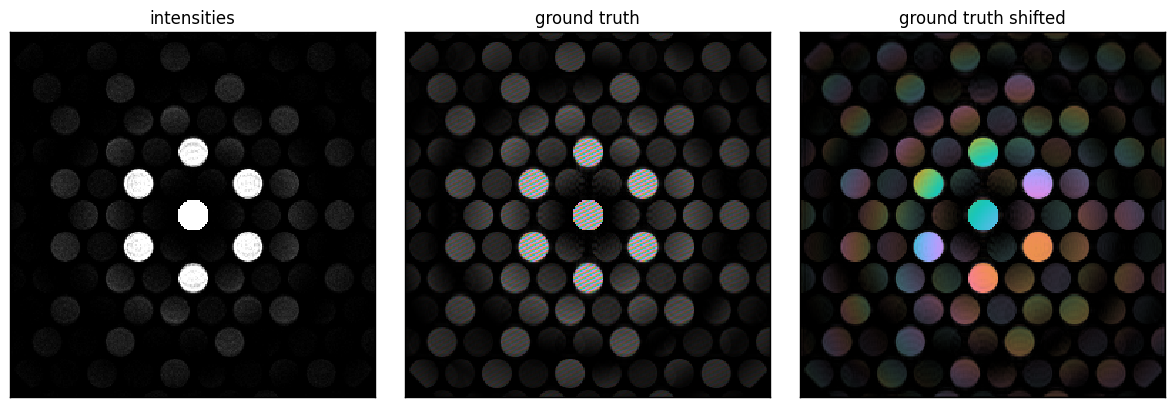

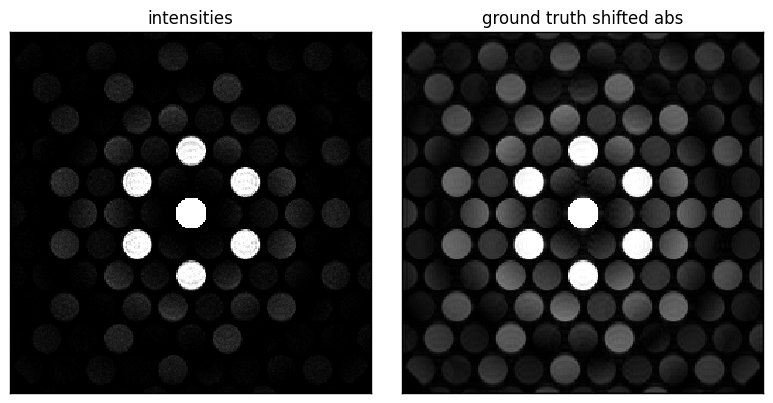

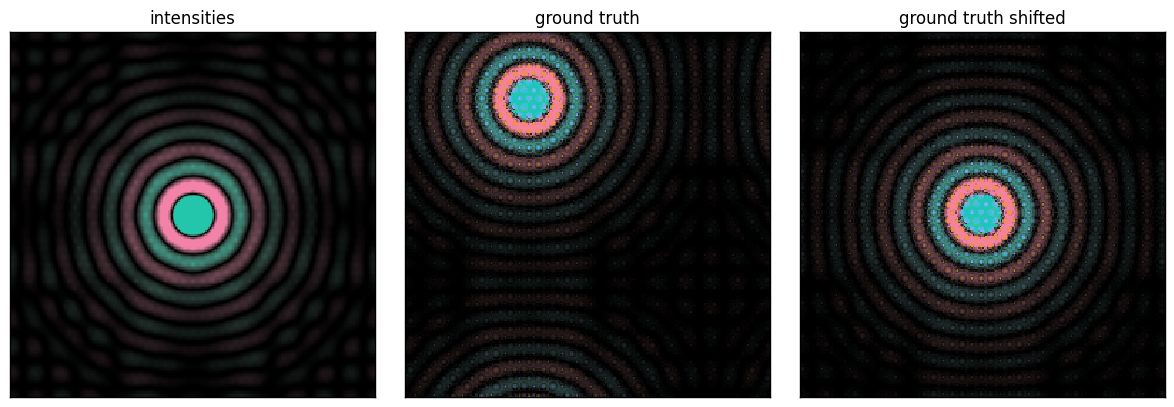

In [8]:
show_2d([pdset.intensities[0], pdset.wave_ground_truth_3d[0], shifted_wave_fourier_space_raveled[0]], title=['intensities', 'ground truth', 'ground truth shifted'])
show_2d([pdset.intensities[0], np.abs(shifted_wave_fourier_space_raveled[0])], title=['intensities', 'ground truth shifted abs'])

show_2d([np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(pdset.intensities, axes=(-2, -1))),axes=(-2, -1))[0],
        np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(pdset.wave_ground_truth_4d, axes=(-2, -1))), axes=(-2, -1))[0, 0],
        shifted_wave_real_space_raveled[0]],
        title=['intensities', 'ground truth', 'ground truth shifted'])



# First row
In the first row of images, the measured measured intensity shows some texture in the disk, but this is not overlap related. The true wave output gives a very high varying phase profile (middle image), when the shift is removed (right image) there is still some phase gradient present. This is likely related to the position within the unit cell

# second row
When considering the intensity of the measured wave and the true wave, we see that, especially in the 7 brightes disks, there is a similar intensity distribution within the disks.

# third row
When considering the real space equivalent of the diffraction pattern, we observe that both intensity and wave measurement have a vivid object and probe contribution. In the wave case, the depth of the object is even visualized. Meaning that this is a purely phase characteristic.


In [9]:
# Intensity patterns (magnitude only, phase lost)
wave_100kev = pdset_100kev.wave_ground_truth_4d  # shape (49, 25, 256, 256)

# Real-space probe×object (no phase ramp, centered)
wave_real_space_100kev = np.fft.fftshift(
    np.fft.ifft2(
        np.fft.ifftshift(wave_100kev, axes=(-2, -1))
    ),
    axes=(-2, -1)
)  # shape (49, 25, 256, 256)

scan_pixel_size = 40 / 48   # Å per scan step
detector_pixel_size = 64 / 256  # Å per detector pixel (0.25 Å/px)
ny_scan, nx_scan = 49, 25
dx = 40 / 48  # Å per pixel
scale = scan_pixel_size / detector_pixel_size  # = (40/48) / (64/256) ≈ 3.333 px/scan-step

iy = (np.arange(ny_scan) - 24) * scale  # in detector pixels
ix = (np.arange(nx_scan) - 12) * scale  # in detector pixels

shifted_wave_real_space_100kev = np.empty_like(wave_real_space_100kev)

for i in range(ny_scan):
    for j in range(nx_scan):
        shifted_wave_real_space_100kev[i, j] = shift(
            wave_real_space_100kev[i, j],
            shift=(-iy[i], -ix[j]),
            mode='wrap'
        )
shp = shifted_wave_real_space_100kev.shape
shifted_wave_real_space_raveled_100kev = shifted_wave_real_space_100kev.reshape((shp[0] * shp[1], shp[2], shp[3]))
shifted_wave_fourier_space_raveled_100kev = np.fft.fftshift(
    np.fft.fft2(
        np.fft.ifftshift(shifted_wave_real_space_raveled_100kev, axes=(-2, -1))
    ),
    axes=(-2, -1)
)  # shape (49x25, 256, 256)

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'intensities zoomed in'}>,
        <Axes: title={'center': 'ground truth zoomed in'}>,
        <Axes: title={'center': 'ground truth shifted zoomed in'}>],
       dtype=object))

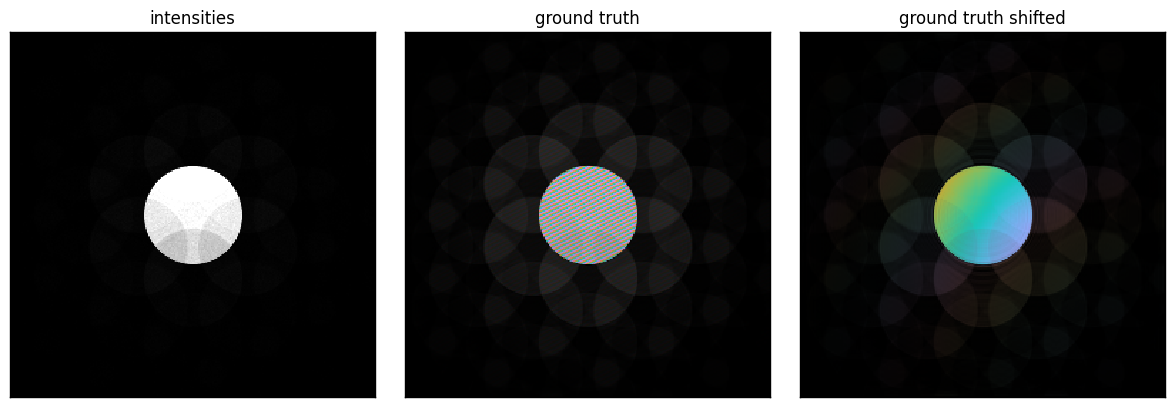

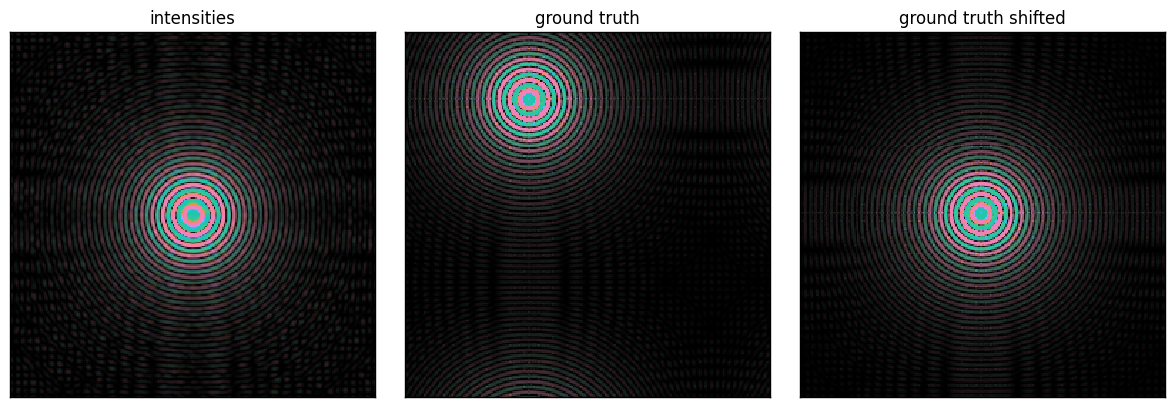

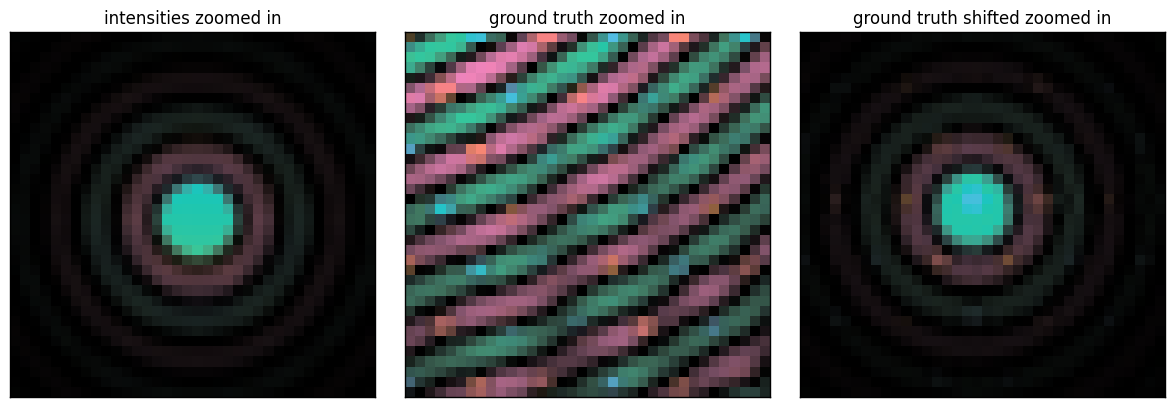

In [10]:
show_2d([pdset_100kev.intensities[0], pdset_100kev.wave_ground_truth_3d[0], shifted_wave_fourier_space_raveled_100kev[0]], title=['intensities', 'ground truth', 'ground truth shifted'])
show_2d([np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(pdset_100kev.intensities, axes=(-2, -1))),axes=(-2, -1))[0],
        np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(pdset_100kev.wave_ground_truth_4d, axes=(-2, -1))), axes=(-2, -1))[0, 0],
        shifted_wave_real_space_raveled_100kev[0]],
        title=['intensities', 'ground truth', 'ground truth shifted'])
show_2d([np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(pdset_100kev.intensities, axes=(-2, -1))),axes=(-2, -1))[0][110:146,110:146],
        np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(pdset_100kev.wave_ground_truth_4d, axes=(-2, -1))), axes=(-2, -1))[0, 0][110:146,110:146],
        shifted_wave_real_space_raveled_100kev[0][110:146,110:146]],
        title=['intensities zoomed in', 'ground truth zoomed in', 'ground truth shifted zoomed in'])


# 100 keV case
The result is quite different from the 10 keV case. 1) there is clearly intensity texture due to disk overlap. 2) in the intenisty based real space visualization, there is no obvious object contribution present. This is present in the wave solution but not nearly as obvious.

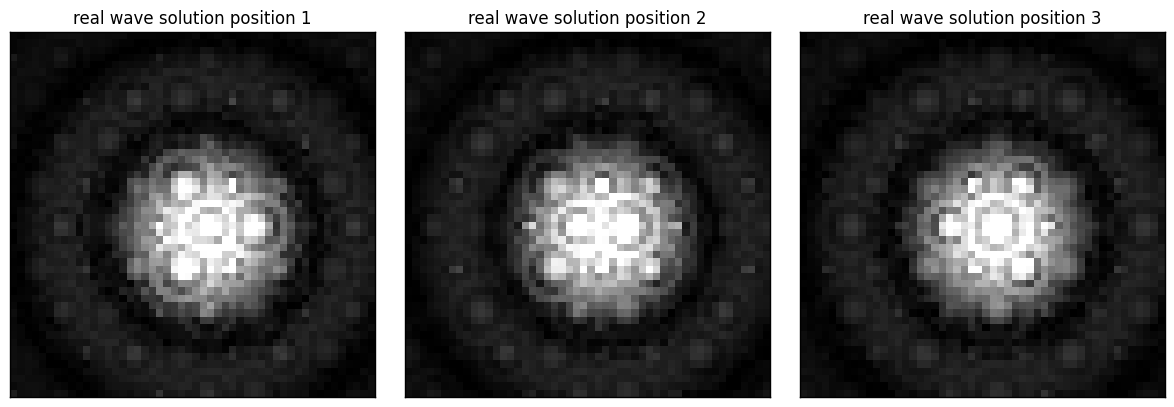

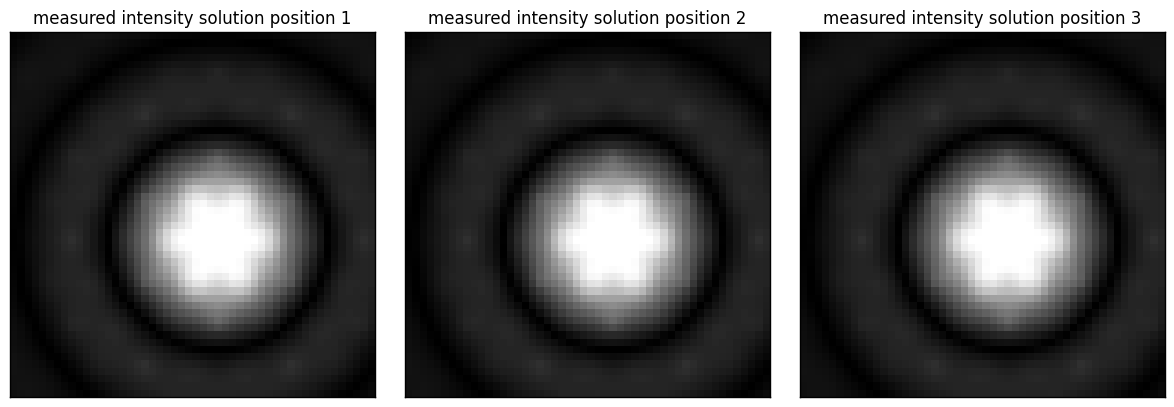

In [11]:
show_2d([np.abs(shifted_wave_real_space_raveled)[0][100:150, 100:150],
        np.abs(shifted_wave_real_space_raveled)[1][100:150, 100:150],
        np.abs(shifted_wave_real_space_raveled)[2][100:150, 100:150]],
        title=['real wave solution position 1', 'real wave solution position 2', 'real wave solution position 3'])

pdset_intensities_real_space = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(pdset.intensities)))

show_2d([np.abs(pdset_intensities_real_space)[0][100:150, 100:150],
        np.abs(pdset_intensities_real_space)[1][100:150, 100:150],
        np.abs(pdset_intensities_real_space)[2][100:150, 100:150]],
        title=['measured intensity solution position 1', 'measured intensity solution position 2', 'measured intensity solution position 3']),
plt.show()


Going back to the 10 keV case. In the wave case, the probe has a clear shift w.r.t. the object (O(r)P(r-R)). But as this information is a phase shift, it is removed when doing an intensity measurement (bottom row). Now the object is always centered with respect to the probe.

(<Figure size 800x400 with 2 Axes>,
 array([<Axes: title={'center': 'full wave average'}>,
        <Axes: title={'center': 'intensity average'}>], dtype=object))

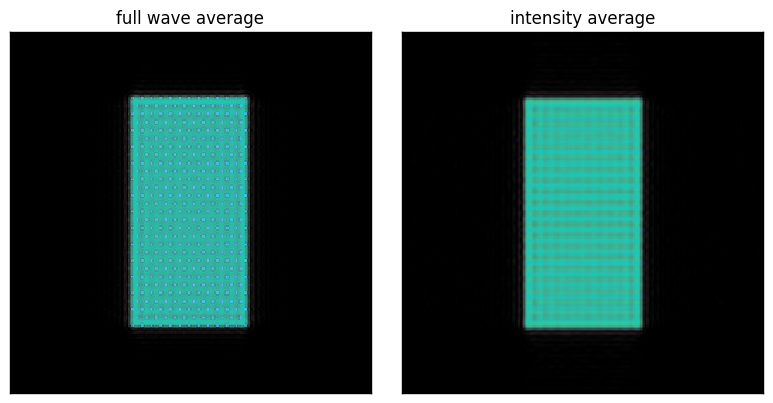

In [12]:
show_2d([np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(pdset_100kev.wave_ground_truth_4d))).mean(axis=(-4,-3)),shifted_intensities_real_space_100kev.mean(axis=(-4,-3))], title=['full wave average', 'intensity average'])



Due to the alignment in the phase channel you can average the wave as reconstruction but this is not possible in the intensity case.

## Analyze the bragg disk contribution from the wave measurement

torch.Size([1225, 256, 256])


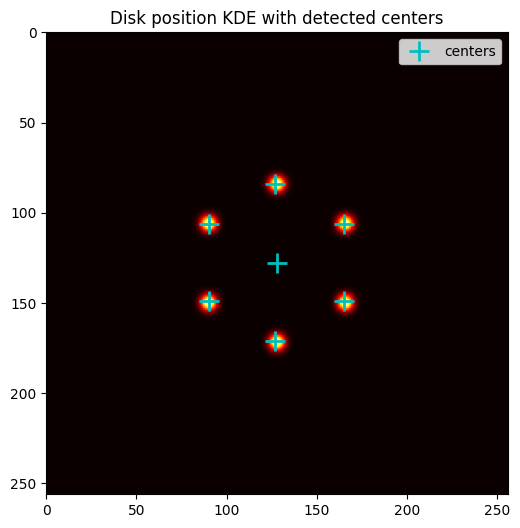

In [13]:
bragg_peaks = detect_bragg_disks(pdset, probe_params, 7, 0.0000001, 5)
bragg_peaks = bragg_disks_to_masks(pdset, probe_params)

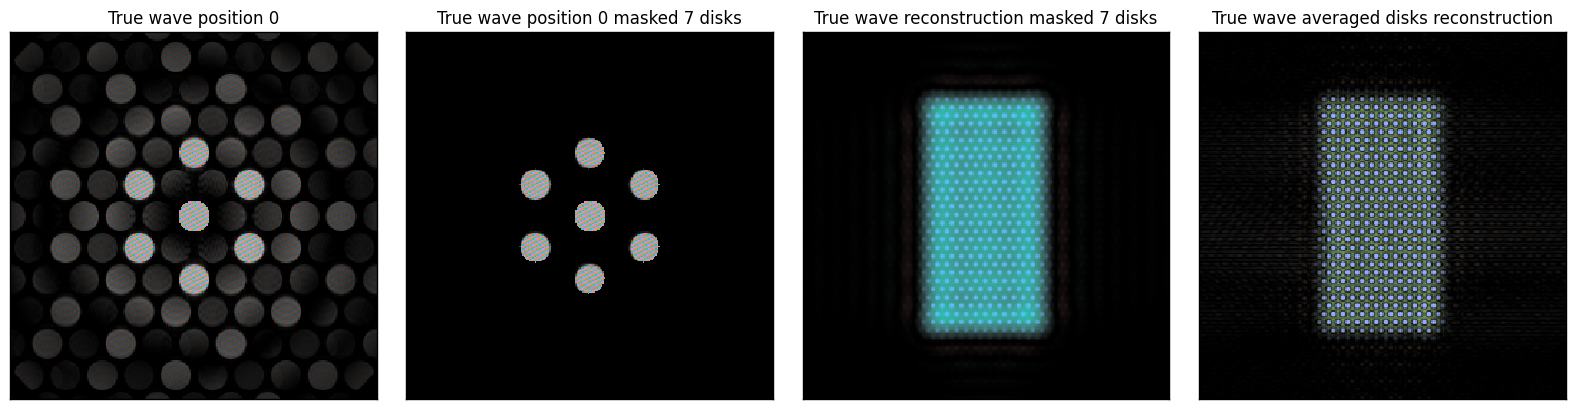

In [14]:
titles = ['True wave position 0', 'True wave position 0 masked 7 disks', 'True wave reconstruction masked 7 disks', 'True wave averaged disks reconstruction']

masked = np.zeros_like(pdset.wave_ground_truth_3d.array)
masked = np.where(pdset.disk_masks, pdset.wave_ground_truth_3d.array, np.zeros_like(pdset.wave_ground_truth_3d.array))

# mean over nonzero pixels per image
nonzero_counts = (np.abs(masked) != 0).sum(axis=(-2, -1), keepdims=True)  # (1225,)
pixel_sums = np.abs(masked).sum(axis=(-2, -1),keepdims=True)              # (1225,)
per_image_mean = pixel_sums / nonzero_counts        # (1225,)


# Replace nonzero pixels with the per-image mean
averaged_disks = np.where(masked != 0, per_image_mean*np.exp(1.0j*np.angle(masked)), 0)                  # (1225, 256, 256)

show_2d([pdset.wave_ground_truth_3d.array[0], masked[0], np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(masked))).mean(axis=(-3)), np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(averaged_disks))).mean(axis=(-3))], title=titles)
plt.show()

In the wave measurement, we can mask everything about except for the first 7 bragg disks, and still be able to get a very good reconstruction (panel 2 and 3). And even when we take out the amplitude information (setting the amplitude of all the non-zero pixels to the average amplitude of these pixels) it is possible to get a reconstruction out. Note that the depth information of the atoms is not present in this masked case

In [ ]:
bragg_peaks = detect_bragg_disks(pdset, probe_params, 19, 0.0000001, 5)
bragg_peaks = bragg_disks_to_masks(pdset, probe_params)

titles = ['True wave position 0', 'True wave position 0 masked 19 disks', 'True wave reconstruction masked 19 disks', 'True wave averaged disks reconstruction']

masked = np.zeros_like(pdset.wave_ground_truth_3d.array)
masked = np.where(pdset.disk_masks, pdset.wave_ground_truth_3d.array, np.zeros_like(pdset.wave_ground_truth_3d.array))

# mean over nonzero pixels per image
nonzero_counts = (np.abs(masked) != 0).sum(axis=(-2, -1), keepdims=True)  # (1225,)
pixel_sums = np.abs(masked).sum(axis=(-2, -1),keepdims=True)              # (1225,)
per_image_mean = pixel_sums / nonzero_counts        # (1225,)


# Replace nonzero pixels with the per-image mean
averaged_disks = np.where(masked != 0, per_image_mean*np.exp(1.0j*np.angle(masked)), 0)                  # (1225, 256, 256)

show_2d([pdset.wave_ground_truth_3d.array[0], masked[0], np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(masked))).mean(axis=(-3)), np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(averaged_disks))).mean(axis=(-3))], title=titles)
plt.show()

torch.Size([1225, 256, 256])


Increasing the amount of disks in the reconstruction from 7 to 19 (choosing the 19 brightes disks), we get a reconstruction that looks a little more involved, but the only qualitative change is that some of the depth information is present again. We again average the amplitude to the same value over all disks, and we still get an acceptable reconstruction with some distinction between the different depth atoms. Underlining the fact that all the important information is in the phase channel.

## Comparing the reconstructed phase channel to the wave measured phase channel

  0%|          | 0/201 [00:00<?, ?it/s]

/home/wdekleijne/git-repos/quantem/src/quantem/diffractive_imaging/object_models.py:386: UserWarning: calculating TV loss for phase, need to check phase wrapping. Easiest fix is scalar phase array.
  warn(


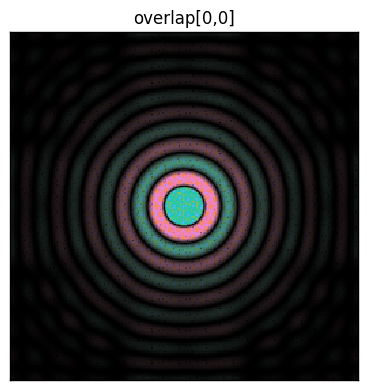

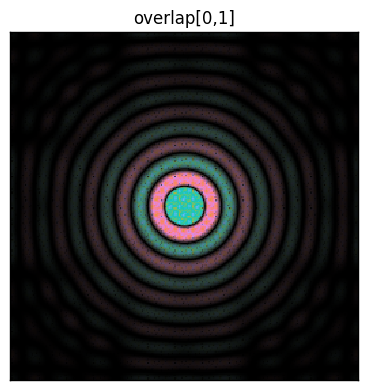

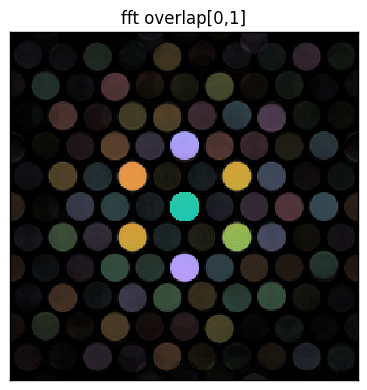

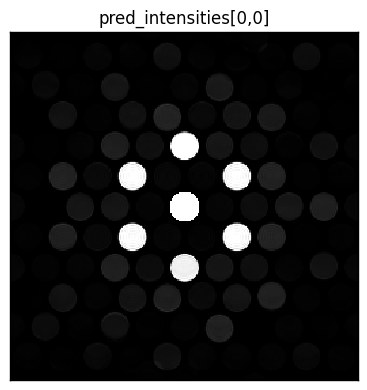

/home/wdekleijne/git-repos/quantem/src/quantem/diffractive_imaging/object_models.py:386: UserWarning: calculating TV loss for phase, need to check phase wrapping. Easiest fix is scalar phase array.
  warn(


fourier_overlap[0,0]: tensor([[-1.3037e+00+0.0530j, -1.0803e+00+0.2852j, -5.1707e-01+0.0474j,
         -3.1022e-02-0.1112j, -1.7535e-02+0.2085j, -9.8687e-02+0.1861j,
         -1.3208e-01+0.0863j, -1.0576e-01+0.1273j, -1.6779e-01+0.0995j,
         -1.4582e-01+0.1511j, -1.8185e-01+0.1445j, -1.5188e-01+0.2579j,
         -1.8907e-01+0.3185j, -1.3286e-01+0.3250j, -1.8603e-01+0.0160j,
         -2.5076e-01-0.3482j],
        [-7.8868e-01+0.2372j, -3.3543e-01-0.1216j, -9.2664e-02-0.1907j,
         -1.8052e-02+0.1572j, -1.3500e-01+0.1780j, -1.8991e-01+0.0828j,
         -1.4501e-01+0.0743j, -1.9820e-01+0.0652j, -1.7486e-01+0.0406j,
         -2.1196e-01+0.0559j, -1.8177e-01+0.1010j, -2.3269e-01+0.1500j,
         -2.1596e-01+0.1954j, -1.9287e-01+0.2530j, -1.3935e-01+0.2710j,
         -8.8488e-02+0.1491j],
        [-8.5947e-02-0.1577j, -7.8212e-02-0.1297j, -6.7806e-02+0.0963j,
         -1.5049e-01+0.1452j, -2.5869e-01+0.0472j, -2.4118e-01+0.0343j,
         -2.2290e-01+0.0161j, -2.3628e-01+0.0129j, -

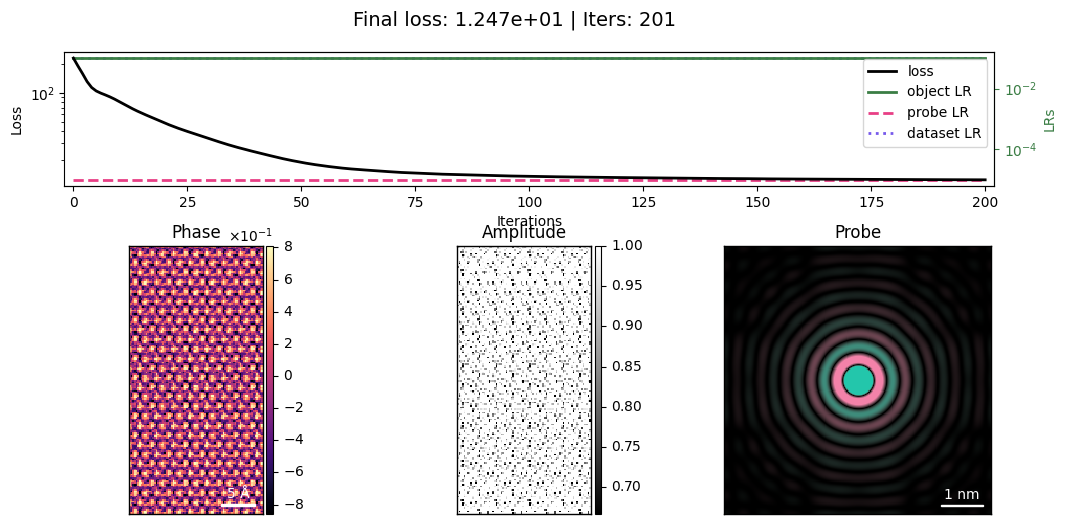

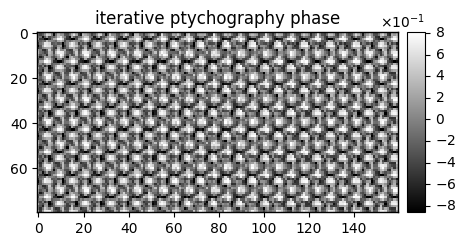

In [ ]:
opt_params = {
        "object": {
            "type": "adamw", 
            "lr": 1e-1, 
        },
        "probe": {
            "type": "adamw", 
            "lr": 1e-5, 
        },
        "dataset": { ### for optimizing over descan shifts and probe positions
            "type": "adamw",
            "lr": 1e-1,
        }
}

scheduler_params = {
    "object": { ## scheduler kwargs are passed to the scheduler (of type type)
        "type": "plateau", ## i like plateau for many cases
        "factor":0.2,

    },
    "probe": {
        "type": "plateau",
        "factor":0.2,

    },
    "dataset": { 
        "type": "plateau",  ## exp is also frequently used 
        "factor":0.2,

    }
}

constraints = {
    "object": {
        "identical_slices": True,
        "positivity": True,
        "fix_potential_baseline": True,
        "fix_potential_baseline_factor": 0.1,  # tune between 0.05–0.5
        "gaussian_sigma": 0.3,      # was "gaussian_filter_sigma" + "gaussian_filter"
        "tv_weight_xy": 0.01,       # was "tv_denoise_weight" + "tv_denoise"
        # optionally also:
        # "q_lowpass": 0.3,         # low-pass frequency cutoff (0–1)
    },
    "dataset": {
        "center_scan_positions": True,
    }
}

constraints_stage1 = {
    "object": {
        "gaussian_sigma": 3.0,      # very heavy
        # "fix_potential_baseline": True,
        # "fix_potential_baseline_factor": 0.5,
        # "positivity": True,
    }
}
constraints_stage2 = {
    "object": {
        # "gaussian_sigma": 0.1,
        "tv_weight_xy": 0.5,
        # "fix_potential_baseline": True,
        # "fix_potential_baseline_factor": 0.1,
        # "positivity": True,
    }
}
# ptycho_pix_reconstruct = ptycho_pix.reconstruct(
#     num_iters=3,
#     reset=True,
#     optimizer_params=opt_params,
#     scheduler_params=scheduler_params,
#     constraints=constraints_stage1, 
#     batch_size=2500,
#     device="cuda:1",
#     store_snapshots_every=1,
#     autograd=False,
#     autograd_random=False,
# )
ptycho_pix_reconstruct = ptycho_pix.reconstruct(
    num_iters=201,
    reset=True,
    optimizer_params=opt_params,
    scheduler_params=scheduler_params,
    constraints=constraints_stage2, 
    batch_size=2500,
    device="cuda:0",
    store_snapshots_every=1,
    autograd=False,
    autograd_random=False,
    disk_phase='disk_phase'
)

print(f'reconstruct: {ptycho_pix_reconstruct}')

ptycho_pix_reconstruct.visualize()

em.visualization.show_2d(
    [
        [
            np.rot90(np.angle(ptycho_pix_reconstruct.obj[0]),k=1),
        ],
    ],
    title=[
        ["iterative ptychography phase"],
    ],
    axsize=(5,5),
    cbar=True,
    show_ticks=True
    
);



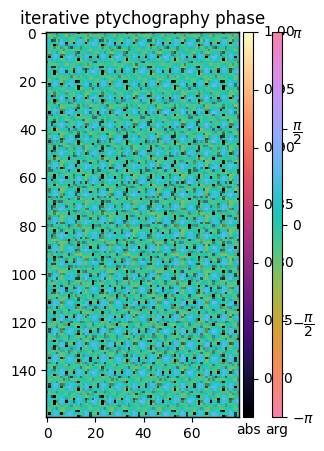

In [ ]:
em.visualization.show_2d(
    [
        [
            ptycho_pix_reconstruct.obj[0],
        ],
    ],
    title=[
        ["iterative ptychography phase"],
    ],
    axsize=(5,5),
    cbar=True,
    show_ticks=True,
    cmap='magma'
);




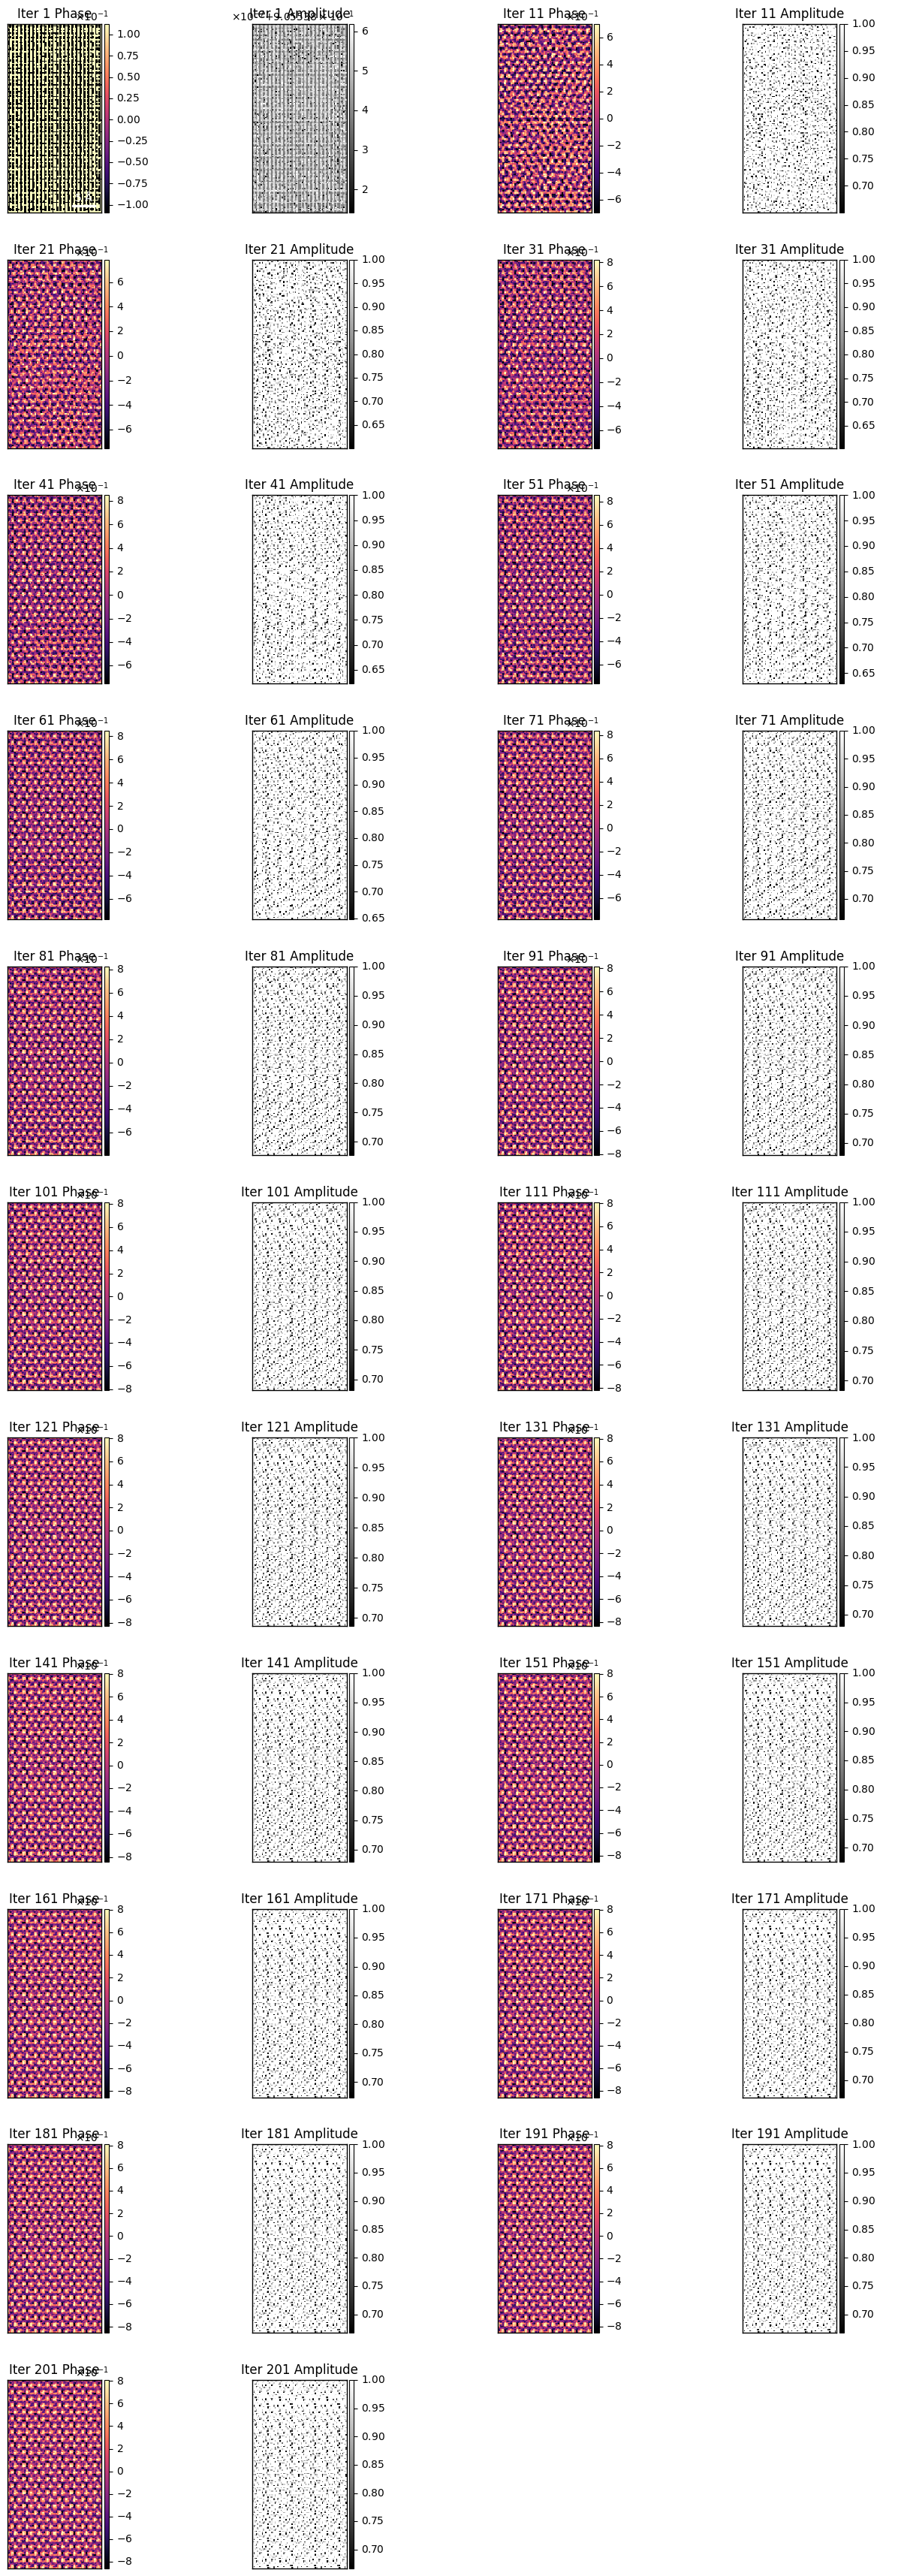

In [ ]:
ptycho_pix_reconstruct.show_iters(
    show_probe=False,
    every_nth=10,
    cmap='magma',
    cbar=True
)

(<Figure size 800x400 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

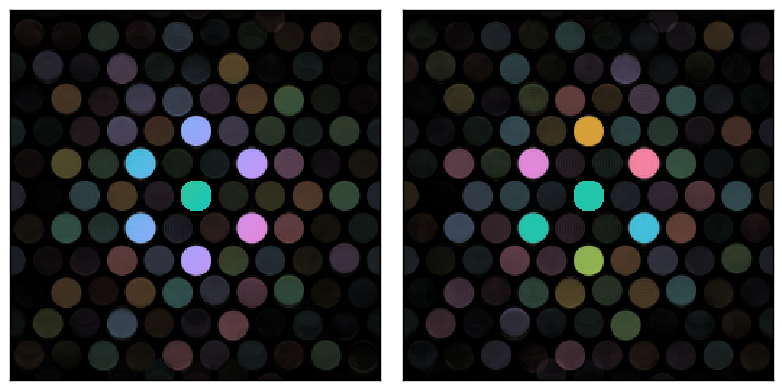

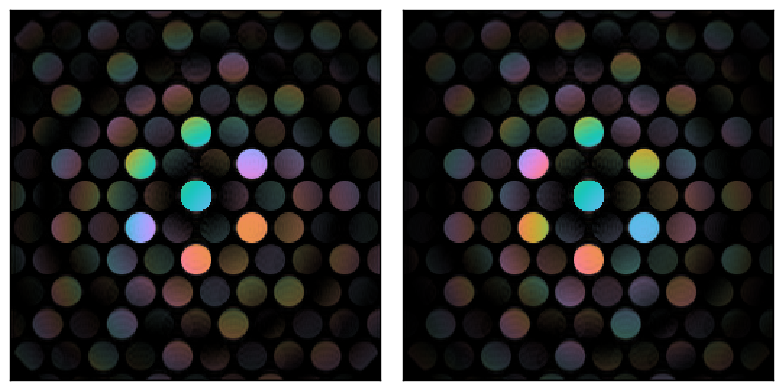

In [ ]:
show_2d([torch.fft.fftshift(torch.fft.fft2(pdset.overlap))[0,0],torch.fft.fftshift(torch.fft.fft2(pdset.overlap)[0,1])])
show_2d([shifted_wave_fourier_space_raveled[0], shifted_wave_fourier_space_raveled[1]])

In this comparison we can see that the ptychography algorithm finds an almost constant phase in every disk (why?). This is contrary to the fact of the wave measurement case where there is some kind of gradient within the disks (which seems more reasonable as there is a mismatch between probe and object). But from the plot below (second row) we can see that the reconstruction does find this shift (also how?). In the reconstruction below we add multislice to try to account for the gradient within the disk, but this only appears to give a very small gradient. Yet, this does give a small increase.

Interestingly, the ptychography converges to a pretty good result (in object terms) but the 8th through 19th bragg disk should be observable at this noise rate, yet there is no depth information visible in the reconstruction.

(<Figure size 800x400 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

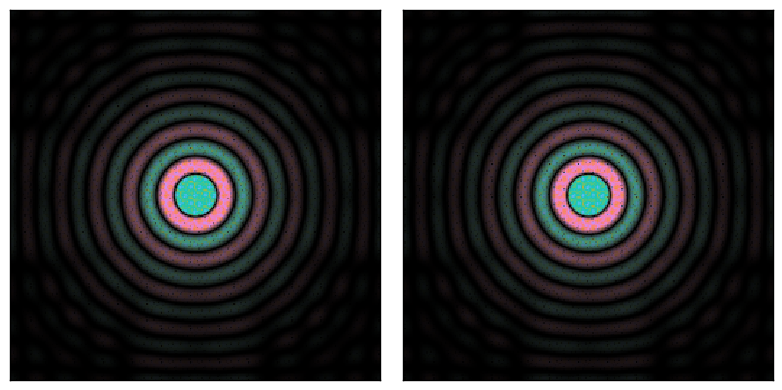

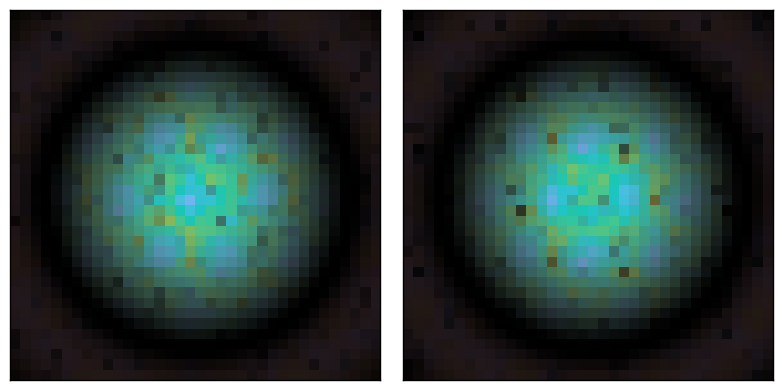

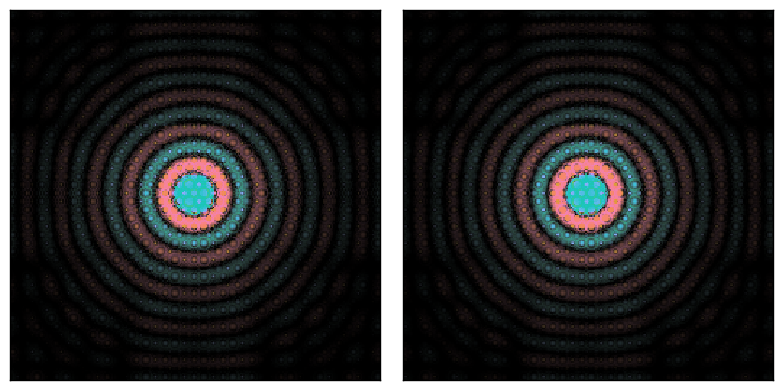

In [ ]:
show_2d([torch.fft.fftshift(pdset.overlap)[0,0],torch.fft.fftshift(pdset.overlap)[0,1]])
show_2d([torch.fft.fftshift(pdset.overlap)[0,0][110:146,110:146],torch.fft.fftshift(pdset.overlap)[0,1][110:146,110:146]])
show_2d([shifted_wave_real_space_raveled[0], shifted_wave_real_space_raveled[1]])

In [ ]:
import matplotlib.pyplot as plt
pdset = PtychographyDatasetRaster.from_dataset4dstem(dset, wave_ground_truth=dset_wave_ground_truth)

probe_params = {
    "energy": PROBE_ENERGY,
    "defocus": PROBE_DEFOCUS,
    "semiangle_cutoff": PROBE_SEMIANGLE,
}
pdset.preprocess(
    force_com_rotation=0,
    force_com_transpose=0,
    plot_com=False,
    probe_energy=PROBE_ENERGY,
)

obj_model_pix = ObjectPixelated.from_uniform( # also from_array and from_random 
    obj_type="complex",
    num_slices=3,
    slice_thicknesses=2,
)

# H, W = 160, 80  # match diffraction / probe grid

# initial_obj = np.ones((1, H, W), dtype=np.complex64)

# obj_model_pix = ObjectPixelated.from_array(
#     initial_obj=initial_obj,
#     obj_type="complex",
# )

probe_params = {
    "energy": PROBE_ENERGY,
    "defocus": PROBE_DEFOCUS,
    "semiangle_cutoff": PROBE_SEMIANGLE,
}
probe_model_pix = ProbePixelated.from_params(
    probe_params=probe_params,
)

detector_model = DetectorPixelated()

# tensorboard logging is optional 
from quantem.diffractive_imaging.logger_ptychography import LoggerPtychography

# logger = None
logger_pix = LoggerPtychography(
    log_dir = "./logs",
    run_prefix=dset.name,
    run_suffix="pix",
    log_images_every=10,
    log_probe_images=False,
)

ptycho_pix = Ptychography.from_models( 
    dset=pdset,
    obj_model=obj_model_pix,
    probe_model=probe_model_pix,
    detector_model=detector_model,
    logger=logger_pix,
    rng=42,
    wave_ground_truth=dset_wave_ground_truth,
)

ptycho_pix.preprocess(
    obj_padding_px=(0, 0),
    val_ratio=0.0,
)

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to 0.


Normalizing intensities:   0%|          | 0/1225 [00:00<?, ?probe position/s]

  0%|          | 0/201 [00:00<?, ?it/s]

/home/wdekleijne/git-repos/quantem/src/quantem/diffractive_imaging/object_models.py:386: UserWarning: calculating TV loss for phase, need to check phase wrapping. Easiest fix is scalar phase array.
  warn(


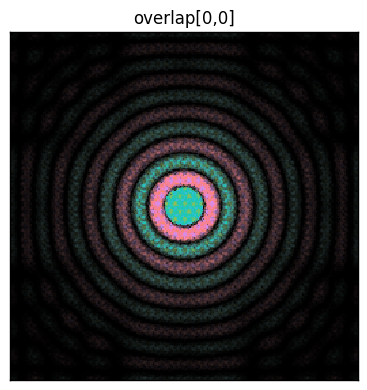

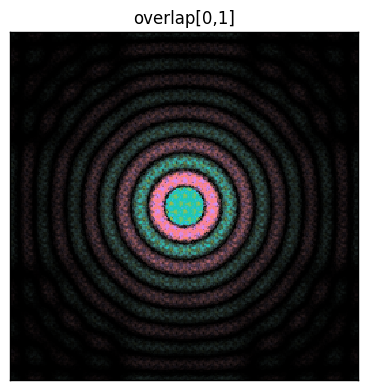

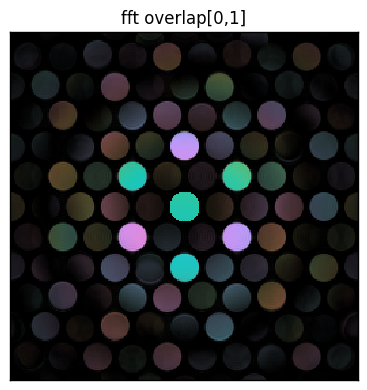

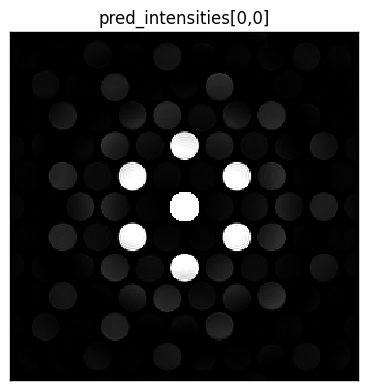

/home/wdekleijne/git-repos/quantem/src/quantem/diffractive_imaging/object_models.py:386: UserWarning: calculating TV loss for phase, need to check phase wrapping. Easiest fix is scalar phase array.
  warn(


fourier_overlap[0,0]: tensor([[-8.0748e-02-0.0984j,  1.2975e-01+0.1058j,  1.1233e-01-0.0390j,
          5.1624e-02-0.2291j,  1.6246e-02-0.2120j,  1.7851e-02-0.2943j,
          7.1206e-02-0.1173j,  6.3340e-02-0.0912j,  7.6872e-02-0.0147j,
          9.1624e-02-0.0238j,  9.2714e-02+0.0668j,  7.7170e-02+0.0912j,
          6.8730e-02+0.1535j,  4.7386e-02+0.0590j,  1.3480e-01+0.1942j,
          1.9202e-01+0.3167j],
        [ 1.4072e-01+0.1177j,  8.1778e-03-0.2391j,  1.2410e-02-0.1925j,
          4.3274e-02-0.2809j,  9.2647e-02-0.2277j,  1.1918e-01-0.2778j,
          1.2441e-01-0.0440j,  1.3782e-01-0.0418j,  1.3490e-01+0.0916j,
          1.1845e-01+0.0215j,  7.3703e-02+0.0940j,  8.7796e-02+0.0894j,
          4.5850e-02+0.1823j,  2.5024e-02+0.1429j, -1.3335e-02+0.1283j,
          9.2986e-02+0.1171j],
        [-6.0565e-02-0.2523j,  8.2763e-03-0.2562j,  2.5398e-02-0.2418j,
          7.1355e-02-0.2896j,  1.3208e-01-0.2379j,  1.7866e-01-0.2234j,
          1.6801e-01-0.0422j,  1.5179e-01-0.0118j,  

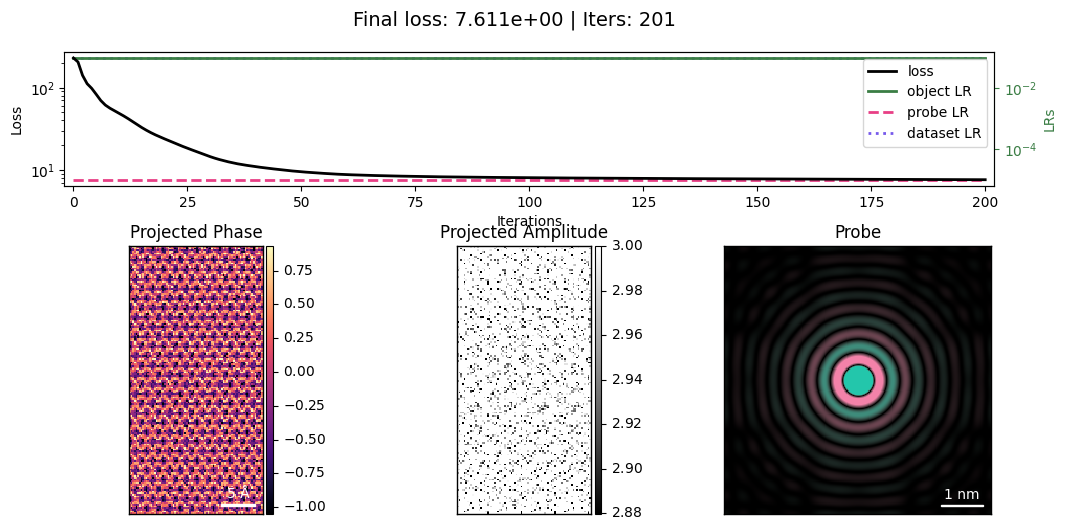

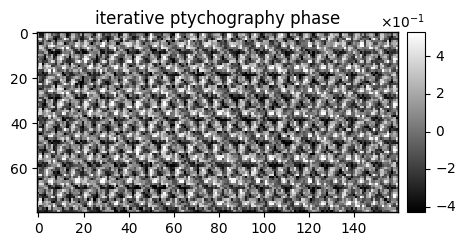

In [ ]:
opt_params = {
        "object": {
            "type": "adamw", 
            "lr": 1e-1, 
        },
        "probe": {
            "type": "adamw", 
            "lr": 1e-5, 
        },
        "dataset": { ### for optimizing over descan shifts and probe positions
            "type": "adamw",
            "lr": 1e-1,
        }
}

scheduler_params = {
    "object": { ## scheduler kwargs are passed to the scheduler (of type type)
        "type": "plateau", ## i like plateau for many cases
        "factor":0.2,

    },
    "probe": {
        "type": "plateau",
        "factor":0.2,

    },
    "dataset": { 
        "type": "plateau",  ## exp is also frequently used 
        "factor":0.2,

    }
}

constraints = {
    "object": {
        "identical_slices": True,
        "positivity": True,
        "fix_potential_baseline": True,
        "fix_potential_baseline_factor": 0.1,  # tune between 0.05–0.5
        "gaussian_sigma": 0.3,      # was "gaussian_filter_sigma" + "gaussian_filter"
        "tv_weight_xy": 0.01,       # was "tv_denoise_weight" + "tv_denoise"
        # optionally also:
        # "q_lowpass": 0.3,         # low-pass frequency cutoff (0–1)
    },
    "dataset": {
        "center_scan_positions": True,
    }
}

constraints_stage1 = {
    "object": {
        "gaussian_sigma": 3.0,      # very heavy
        # "fix_potential_baseline": True,
        # "fix_potential_baseline_factor": 0.5,
        # "positivity": True,
    }
}
constraints_stage2 = {
    "object": {
        # "gaussian_sigma": 0.1,
        "tv_weight_xy": 0.5,
        # "fix_potential_baseline": True,
        # "fix_potential_baseline_factor": 0.1,
        # "positivity": True,
    }
}
# ptycho_pix_reconstruct = ptycho_pix.reconstruct(
#     num_iters=3,
#     reset=True,
#     optimizer_params=opt_params,
#     scheduler_params=scheduler_params,
#     constraints=constraints_stage1, 
#     batch_size=2500,
#     device="cuda:1",
#     store_snapshots_every=1,
#     autograd=False,
#     autograd_random=False,
# )
ptycho_pix_reconstruct = ptycho_pix.reconstruct(
    num_iters=201,
    reset=True,
    optimizer_params=opt_params,
    scheduler_params=scheduler_params,
    constraints=constraints_stage2, 
    batch_size=2500,
    device="cuda:0",
    store_snapshots_every=1,
    autograd=False,
    autograd_random=False,
    disk_phase='disk_phase'
)

print(f'reconstruct: {ptycho_pix_reconstruct}')

ptycho_pix_reconstruct.visualize()

em.visualization.show_2d(
    [
        [
            np.rot90(np.angle(ptycho_pix_reconstruct.obj[0]),k=1),
        ],
    ],
    title=[
        ["iterative ptychography phase"],
    ],
    axsize=(5,5),
    cbar=True,
    show_ticks=True
    
);



(<Figure size 800x400 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

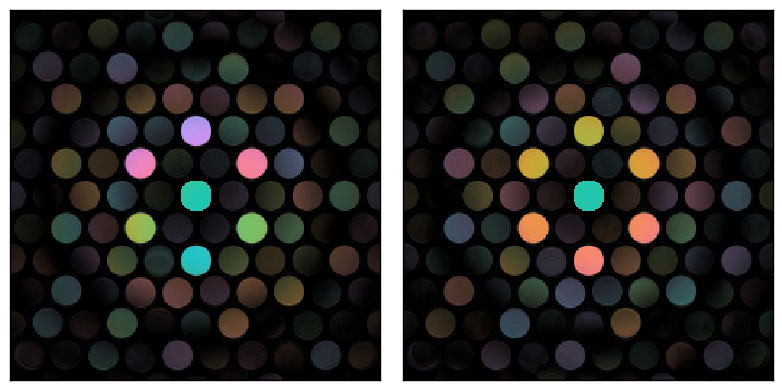

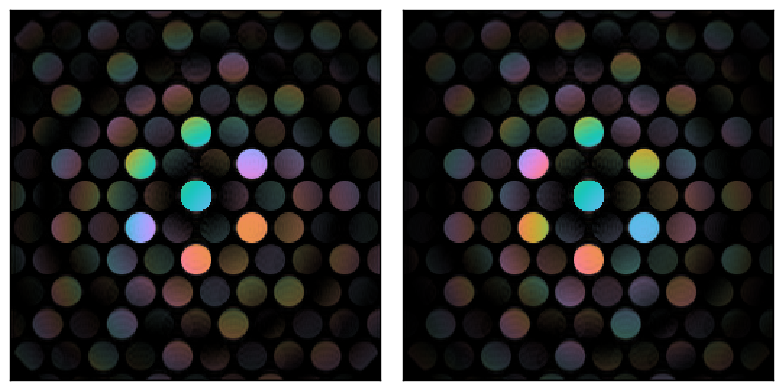

In [ ]:
show_2d([torch.fft.fftshift(torch.fft.fft2(pdset.overlap))[0,0],torch.fft.fftshift(torch.fft.fft2(pdset.overlap)[0,1])])
show_2d([shifted_wave_fourier_space_raveled[0], shifted_wave_fourier_space_raveled[1]])